# Estimating Mass Change from GRACE Measurements on a 2D Earth

This notebook provides example calculation to estimate mass change from repreat-pass GRACE measurements of inter-satellite difference. The data for this notebook was generated in the previous notebooks demonstrating how mass anomalies (like a big ice sheet) induce changes in the distance between the satellites. Here, we turn this calculation around and see if we can recover the mass change signal.

Let's read in some modules for this notebook:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

## A 2D Earth with an Ice Sheet

In the previous notebook, we set up a 2D earth with an ice sheet that had the following parameters:

In [2]:
R = 6.371e6                 # radius of Earth, m
phi_G1 = np.deg2rad(60)     # starting latitude of the ice sheet
phi_G2 = np.deg2rad(84)     # ending latitude of the ice sheet
rho_ice = 917               # density of ice, kg/m^2
H_ice = 1000                # initial thickness of ice, m
G = 6.6743e-11              # gravitational constant of the universe, m3 / kg / s2

We also implemented some parameters for GRACE:

In [3]:
v_s = 7.6e3   # speed over ground, m/s
L_0 = 2.2e5   # inter-satellite distance, m
h = 4.5e5     # elevation above Earth surface, m

Using these parameters, we compute the change in distance between the satellites in two different orbits: one before the ice sheet underwent change, and one after the ice sheet thinned uniformly by 10 m. Let's read in that data here:

In [4]:
timeseries_before = np.genfromtxt('delta_L_before_change.csv', delimiter=',')
phi_orbit = timeseries_before[:,0]
delta_L_before = timeseries_before[:,1]

timeseries_after = np.genfromtxt('delta_L_after_change.csv', delimiter=',')
delta_L_after = timeseries_after[:,1]

As a reminder, the inter-satellite distances look as follows:

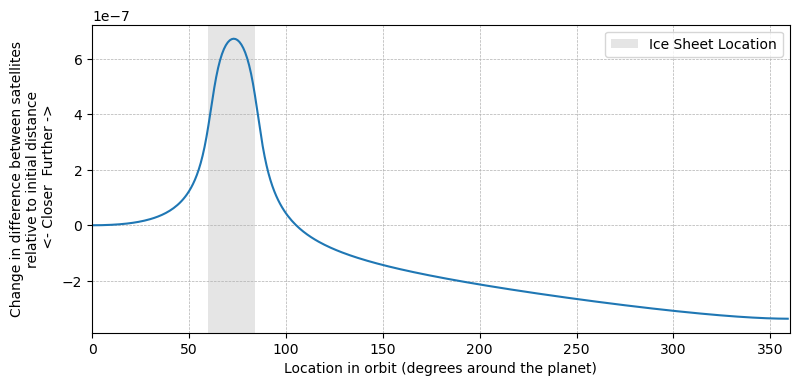

In [5]:
phi_orbit_deg = np.rad2deg(phi_orbit)

plt.figure(figsize=(9,4))

# plot the along track distance differences
plt.plot(phi_orbit_deg, delta_L_after)
ymin, ymax = plt.gca().get_ylim()

# plot the location of the ice sheet
rect = Rectangle((np.rad2deg(phi_G1), ymin),
                 np.rad2deg(phi_G2-phi_G1), ymax-ymin,
                 facecolor='silver', alpha=0.4, label='Ice Sheet Location')
plt.gca().add_patch(rect)

# label the axes
plt.ylabel('Change in difference between satellites\nrelative to initial distance\n <- Closer  Further ->')
plt.xlabel('Location in orbit (degrees around the planet)') 
plt.xlim([0,360])
plt.grid(linestyle='--',linewidth=0.5)
plt.legend()
plt.show()

## Computing Gravity Anomalies from Satellite Distances

The relative acceleration of the satellites is related to the changes in distance between them as 

$$
a_{rel} = \frac{d^2 \Delta L}{dt}
$$

We can estimate this derivative along the orbit using a centered-difference:

$$
a_{rel, n} \approx \frac{\Delta L_{n+1} -2\Delta L_{n} + \Delta L_{n-1}}{\Delta t^2}
$$

Let's compute that here:

In [6]:
# compute delta t
delta_t = (2*np.pi*(R+h)/(360*v_s))

# compute the relative differences from both orbits
a_L_before = (delta_L_before[2:] - 2 * delta_L_before[1:-1] + delta_L_before[:-2]) / delta_t**2
a_L_after = (delta_L_after[2:] - 2 * delta_L_after[1:-1] + delta_L_after[:-2]) / delta_t**2

Next, we will use this information to compute the along-track gravity anomalies. Here, we estimate the anomalies using a Fourier approximation:

$$
g_{along}(\phi) \approx \sum_{m=1}^M \left[ A_m \cos (m \phi) + B_m \sin (m \phi) \right]
$$

Here, $M$ is the order of the approximation. For reference, most GRACE estimates use order 60.

Since the GRACE estimates yield $a_{rel}$, we have

$$
\begin{align*}
a_{rel} & = g_{1, along}(\phi) - g_{2, along}(\phi)\\
&= g_{along}(\phi) - g_{along}(\phi-\alpha)\\
&\approx \sum_{m=1}^M \left[ A_m \cos (m \phi) + B_m \sin (m \phi) \right] - \sum_{m=1}^M \left[ A_m \cos (m (\phi-\alpha)) + B_m \sin (m (\phi-\alpha)) \right] \\
&= \sum_{m=1}^M \left[ A_m (\cos (m \phi)-\cos (m (\phi-\alpha))) + B_m (\sin (m \phi)-\sin (m (\phi-\alpha))) \right]
\end{align*}
$$

Thus, using our $N$ estimates of $\Delta L$ and an order $M$ Fourier approximatetion, we have a system of $N$ equations with $M$ unknowns we can write as follows:

$$
\textbf{a} = \textbf{X} \boldsymbol\beta
$$

where $X$ is a design matrix with two columns for $(\cos (m \phi)-\cos (m (\phi-\alpha))$ and $(\sin (m \phi)-\sin (m (\phi-\alpha)))$, and the $\boldsymbol\beta$ matrix holds the coefficients $A_m$'s and $B_m$'s

In effect, there is not a unique solution for the $A_m$'s and $B_m$'s, but we can estimate the optimal parameters using a least squares fit:

$$
\boldsymbol\beta = (\textbf{X}^T\textbf{X})^{-1}\textbf{X}^T \textbf{a}
$$

In [7]:
# angular separation in radians
alpha = L_0/(R+h)
phi_orbit_short = phi_orbit[1:-1]
phi_orbit_trail_short = phi_orbit_short - alpha

# make the design matrix
M = 60
columns = []
for m in range(1, M + 1):
    columns.append(np.cos(m * phi_orbit_short) - np.cos(m * phi_orbit_trail_short))
    columns.append(np.sin(m * phi_orbit_short) - np.sin(m * phi_orbit_trail_short))
X = np.column_stack(columns)

# compute the coefficients
coeffcients_before = np.linalg.inv(X.T@X)@X.T@a_L_before
coeffcients_after = np.linalg.inv(X.T@X)@X.T@a_L_after

Using these coefficients, we can reconstruct the along-track gravity for a satellite at any location along the orbit:

In [8]:
# make arrays to store g
g_before = np.zeros_like(phi_orbit, dtype=float)
g_after = np.zeros_like(phi_orbit, dtype=float)

# loop through to fill in the gravity estimates using the harmonics
for m in range(1, M + 1):
    
    # run the before calculation 
    A_m = coeffcients_before[2 * (m - 1)]
    B_m = coeffcients_before[2 * (m - 1) + 1]
    g_before += A_m * np.cos(m * phi_orbit) + B_m * np.sin(m * phi_orbit)

    # then the after calculation 
    A_m = coeffcients_after[2 * (m - 1)]
    B_m = coeffcients_after[2 * (m - 1) + 1]
    g_after += A_m * np.cos(m * phi_orbit) + B_m * np.sin(m * phi_orbit)

Let's see what these curves looks like:

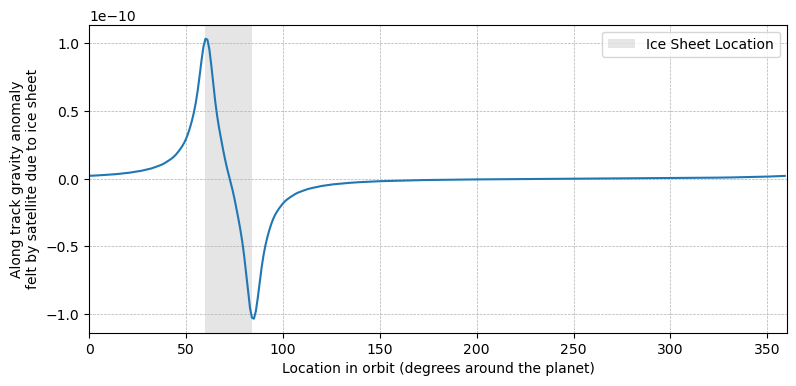

In [9]:
plt.figure(figsize=(9,4))

# plot the along track gravity anomaly
plt.plot(phi_orbit_deg, g_after)
ymin, ymax = plt.gca().get_ylim()

# plot the location of the ice sheet
rect = Rectangle((np.rad2deg(phi_G1), ymin),
                 np.rad2deg(phi_G2-phi_G1), ymax-ymin,
                 facecolor='silver', alpha=0.4, label='Ice Sheet Location')
plt.gca().add_patch(rect)

# label the axes
plt.ylabel('Along track gravity anomaly\nfelt by satellite due to ice sheet')
plt.xlabel('Location in orbit (degrees around the planet)') 
plt.xlim([0,360])
plt.grid(linestyle='--',linewidth=0.5)
plt.legend()
plt.show()

Comparing this with the previous notebook, we can see that this is a pretty good fit! Ok, now what about the mass changes?

## Mass Change with Mass-Conserving Bins (a.k.a. Mascons)

One way we can estimate mass changes on the Earth surface is to set up a finite number of areas of constant density and estimate how changes in each would contribute to the overall changes in the gravity anomaly signal. As an example, consider that have mascons of size 1 degree so that there are 360 mascons coverage the surface of our 2D earth.

As shown in the previous notebook, the $j^{th}$ mascon with a given density and thickness of ice between $\phi_j$ and $\phi_{j+1}$ will contribute the following gravitational acceleration in the along-track direction:
$$
g_{along}(\phi_s)_j = \frac{G \rho_i H_i R}{R+h} \left[\frac{1}{d(\phi_j - \phi_s)} - \frac{1}{d(\phi_{j+1} - \phi_s)}\right] 
$$

If we knew $H_i$(j), the collection of mascons around the Earth would contribute to the following to the along-track gravity anomaly:

$$
g_{along}(\phi_s) = \sum_{j=1}^J g_{along}(\phi_s)_j = \sum_{j=1}^J \frac{G \rho_i H_{i,j} R}{R+h} \left[\frac{1}{d(\phi_j - \phi_s)} - \frac{1}{d(\phi_{j+1} - \phi_s)}\right] 
$$

However, we'd don't know $H_{i,j}$ - this is what we're trying to figure out using our observations. We can make one small change here to clean up the math a bit for coding. If we define the following:

$$
K_j = \frac{G \rho_i R}{R+h} \left[\frac{1}{d(\phi_j - \phi_s)} - \frac{1}{d(\phi_{j+1} - \phi_s)}\right] 
$$

then we can write 

$$
g_{along}(\phi_s) = \sum_{j=1}^J H_{i,j} K_j
$$

Using this formulation, we can see we effectively have a linear system of equations! We have our estimate of $g_{along}(\phi_s)$ and we have the information to compute $K_j$ in each mascon. Let's do this here:

In [10]:
def distance_to_surface_point(theta):
    return np.sqrt(R**2 + (R+h)**2 - 2*R*(R+h)*np.cos(theta))

def mascon_K(phi, a, b):
    d_a = distance_to_surface_point(a - phi)
    d_b = distance_to_surface_point(b - phi)

    return (G * rho_ice * R / (R+h)) * (1/d_a - 1/d_b)

# Choose number of mascons around the circle
J = 120

edges = np.linspace(0, 2*np.pi, J + 1)

# Build K matrix
# Rows = observations
# Columns = mascons
K = np.zeros((len(phi_orbit), J))

for j in range(J):
    a = edges[j]
    b = edges[j + 1]
    K[:, j] = mascon_K(phi_orbit, a, b)

With $K$ in hand, we can now compute the elevation changes:

In [11]:
delta_H = np.linalg.inv(K.T@K)@K.T@(g_after-g_before)

Let's see how things look:

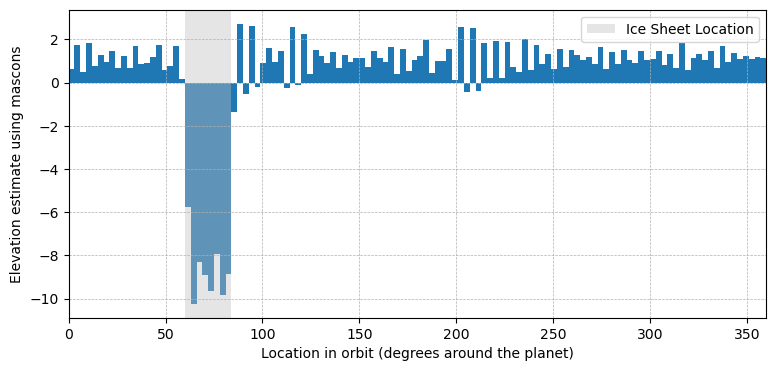

In [12]:
plt.figure(figsize=(9,4))

# plot the along track gravity anomaly
plt.bar(np.rad2deg((edges[:-1] + edges[1:])/2), delta_H, width=3)
ymin, ymax = plt.gca().get_ylim()

# plot the location of the ice sheet
rect = Rectangle((np.rad2deg(phi_G1), ymin),
                 np.rad2deg(phi_G2-phi_G1), ymax-ymin,
                 facecolor='silver', alpha=0.4, label='Ice Sheet Location')
plt.gca().add_patch(rect)

# label the axes
plt.ylabel('Elevation estimate using mascons')
plt.xlabel('Location in orbit (degrees around the planet)') 
plt.xlim([0,360])
plt.grid(linestyle='--',linewidth=0.5)
plt.legend()
plt.show()

There a few things to note here. First, we can see that the estimate is providing a reasonable estimate of the mass loss represented by an elevation change of 10 m. Second, its not a perfect solution - some of the elevation changes are observed in locations outside of the ice sheet region!

## Mass Change Computed with Harmonics

With harmonics, we make the assumption that

$$
g_{along}(\phi_s) \approx \sum_{m=1}^M \left[ A_m \cos (m \phi) + B_m \sin (m \phi) \right]
$$

Similar to mascons we can organize this as a system of equations

$$
g_{along}(\phi_s) = \sum_{j=1}^J H_{i,j} K_j
$$

In [20]:
def distance(theta):
    dist = np.sqrt(R**2 + (R+h)**2 -2*R*(R+h)*np.cos(theta))
    return(dist)

def gravity_from_surface_density(phi_s, sigma_psi):
    dpsi = 2*np.pi / len(sigma_psi)
    theta = phi_orbit - phi_s
    d = distance(theta)
    kernel = G * rho_ice * R * (R * np.sin(theta)) / d**3
    return np.sum(kernel * sigma_psi * dpsi)

In [21]:
# Build design matrix
columns = []

for m in range(1, M + 1):
    g_basis_cos = np.array([
        gravity_from_surface_density(phi_s, np.cos(m * phi_orbit))
        for phi_s in phi_orbit
    ])
    columns.append(g_basis_cos)
    
    g_basis_sin = np.array([
        gravity_from_surface_density(phi_s, np.sin(m * phi_orbit))
        for phi_s in phi_orbit
    ])
    columns.append(g_basis_sin)
    
X = np.column_stack(columns)

With this in hand, let's compute the coefficients

In [24]:
# Solve for surface-density harmonic coefficients
print(np.shape(X), np.shape(g_after - g_before))
coeff_sigma = np.linalg.inv(X.T@X)@X.T@(g_after - g_before)

(360, 120) (360,)


Now that we've got this, we can now estimate $\delta H$.

In [26]:
phi_grid_dense = np.linspace(0, 2*np.pi, 500, endpoint=False)

delta_H = np.zeros_like(phi_grid_dense, dtype=float)

idx = 0
for m in range(1, M + 1):
    P_m = coeff_sigma[idx]
    Q_m = coeff_sigma[idx + 1]
    idx += 2

    delta_H += P_m*np.cos(m*phi_grid_dense)
    delta_H += Q_m*np.sin(m*phi_grid_dense)

Let's see what this looks like:

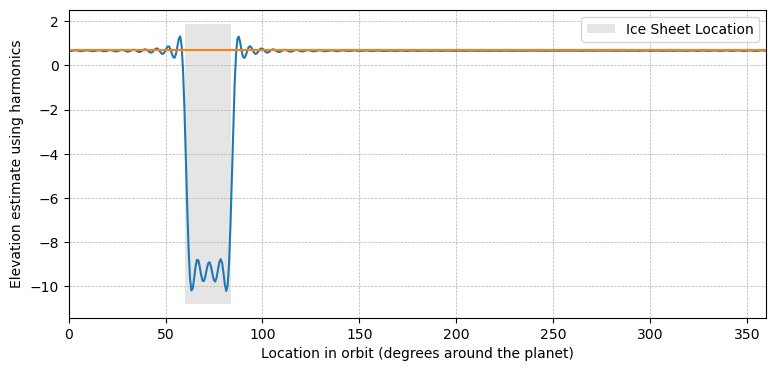

In [27]:
plt.figure(figsize=(9,4))

# plot the along track gravity anomaly
plt.plot(np.rad2deg(phi_grid_dense), delta_H)
ymin, ymax = plt.gca().get_ylim()

plt.plot([0,360],[ 0.72, 0.72])

# plot the location of the ice sheet
rect = Rectangle((np.rad2deg(phi_G1), ymin),
                 np.rad2deg(phi_G2-phi_G1), ymax-ymin,
                 facecolor='silver', alpha=0.4, label='Ice Sheet Location')
plt.gca().add_patch(rect)

# label the axes
plt.ylabel('Elevation estimate using harmonics')
plt.xlabel('Location in orbit (degrees around the planet)') 
plt.xlim([0,360])
plt.grid(linestyle='--',linewidth=0.5)
plt.legend()
plt.show()

As we can see, the solution from the harmonics has a similar form as the mascon solution - it approximates the same 10 m decline in ice sheet thickness.